In [ ]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.andrews import encode, normalize_data, andrews_curve

In [2]:
df = pd.read_csv("../data/winequality-red.csv", sep=";")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
X = df.drop(columns=["quality"])
y = df["quality"]

print("Forma del dataset:", df.shape)
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Variables usadas:", list(X.columns))
print("Calidades disponibles:", sorted(y.unique()))

Forma del dataset: (1599, 12)
Forma de X: (1599, 11)
Forma de y: (1599,)
Variables usadas: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Calidades disponibles: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


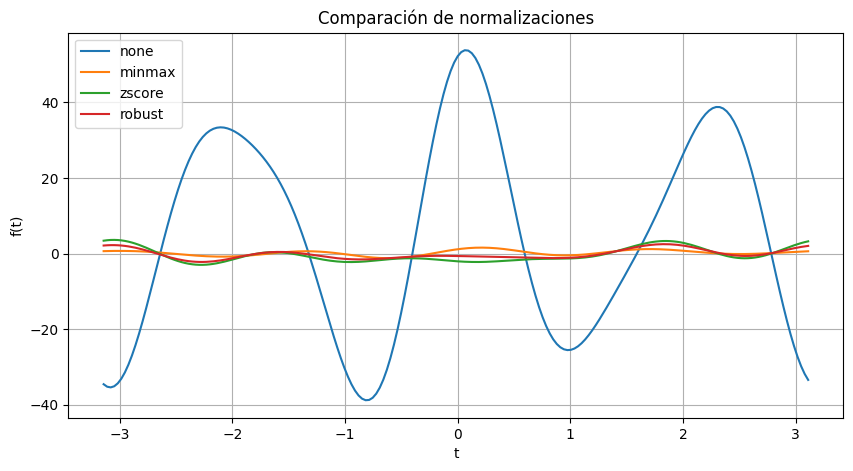

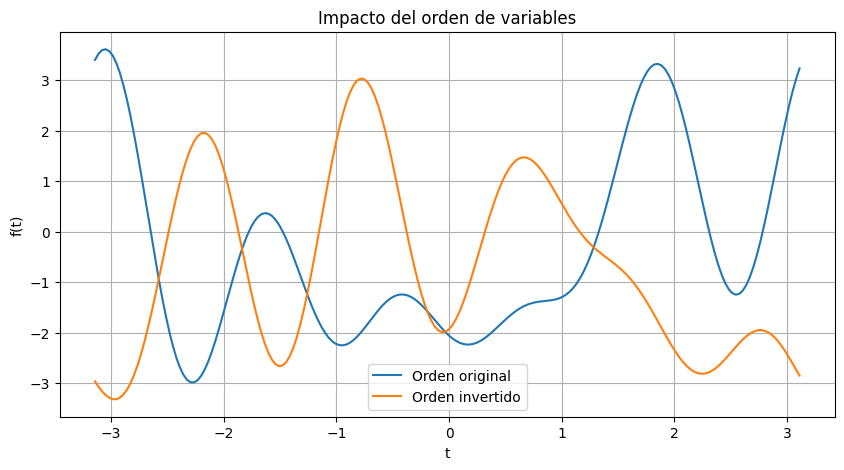

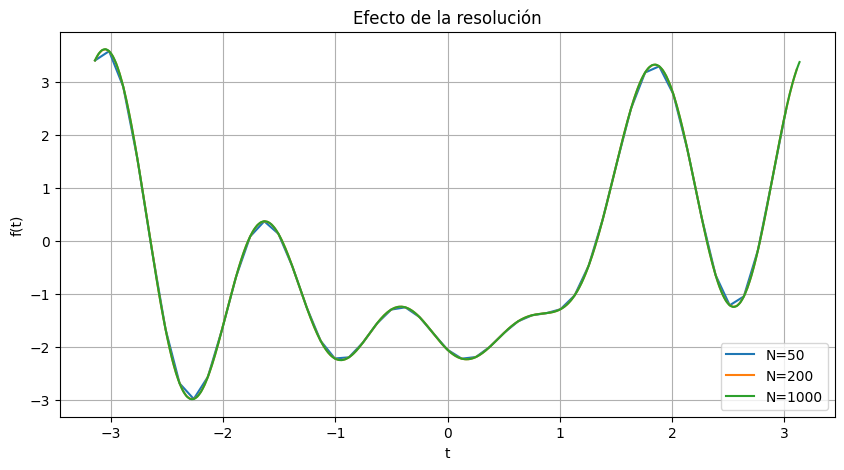

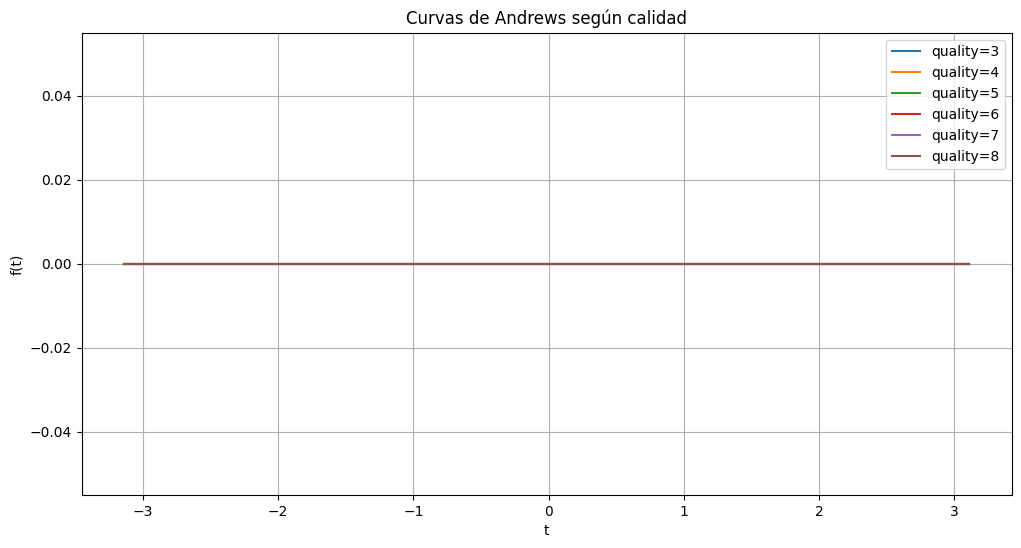

In [4]:

# ========================= 
# 1. Comparar normalizaciones 
# =========================

sample = X

curves_none, t = encode(sample, normalize="none", return_t=True)
curves_minmax = encode(sample, normalize="minmax")
curves_zscore = encode(sample, normalize="zscore")
curves_robust = encode(sample, normalize="robust")

plt.figure(figsize=(10, 5))

plt.plot(t, curves_none[0], label="none")
plt.plot(t, curves_minmax[0], label="minmax")
plt.plot(t, curves_zscore[0], label="zscore")
plt.plot(t, curves_robust[0], label="robust")

plt.title("Comparación de normalizaciones")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 2. Comparar orden de variables
# =========================

original_order = list(range(X.shape[1]))
reverse_order = original_order[::-1]

curves_original, t = encode(
    sample,
    normalize="zscore",
    order=original_order,
    return_t=True
)

curves_reverse = encode(
    sample,
    normalize="zscore",
    order=reverse_order
)

plt.figure(figsize=(10, 5))

plt.plot(t, curves_original[0], label="Orden original")
plt.plot(t, curves_reverse[0], label="Orden invertido")

plt.title("Impacto del orden de variables")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 3. Comparar resolución N
# =========================

curve_50, t50 = encode(sample, N=50, return_t=True)
curve_200, t200 = encode(sample, N=200, return_t=True)
curve_1000, t1000 = encode(sample, N=1000, return_t=True)

plt.figure(figsize=(10, 5))

plt.plot(t50, curve_50[0], label="N=50")
plt.plot(t200, curve_200[0], label="N=200")
plt.plot(t1000, curve_1000[0], label="N=1000")

plt.title("Efecto de la resolución")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


# =========================
# 4. Curvas según calidad
# =========================

qualities = [3,4,5,6,7,8]

plt.figure(figsize=(12, 6))

for q in qualities:
    idx = y[y == q].index[0]

    sample_q = X.loc[[idx]]

    curve_q, t = encode(
        sample_q,
        normalize="zscore",
        return_t=True
    )

    plt.plot(t, curve_q[0], label=f"quality={q}")

plt.title("Curvas de Andrews según calidad")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.grid(True)
plt.show()


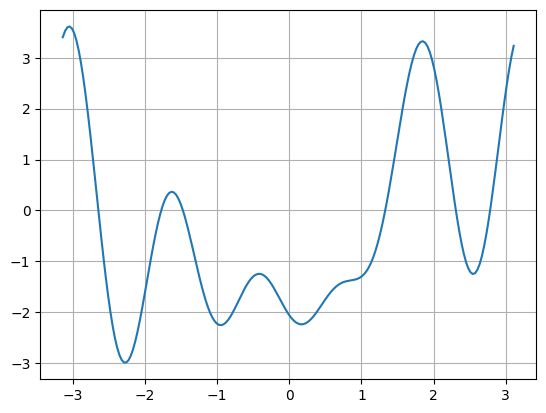

In [11]:
curves, t = encode(
    X,
    normalize="zscore",
    return_t=True
)

plt.plot(t, curves[0])
plt.grid()

In [12]:
from scipy.signal import find_peaks

curve = curves[0]

peaks, _ = find_peaks(curve)
valleys, _ = find_peaks(-curve)

print("Peaks:", len(peaks))
print("Valleys:", len(valleys))

Peaks: 4
Valleys: 4


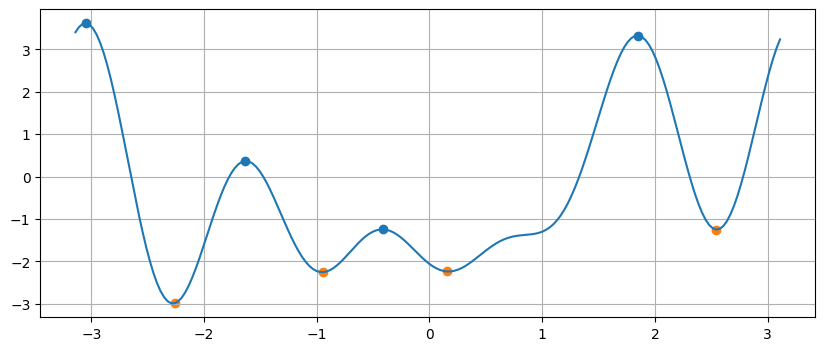

In [13]:
plt.figure(figsize=(10,4))
plt.plot(t, curve)

plt.scatter(t[peaks], curve[peaks])
plt.scatter(t[valleys], curve[valleys])

plt.grid(True)
plt.show()

In [28]:
from src.sublevel_persistence import (
    persistence_diagram,
    persistence_statistics,
    build_periodic_complex
)

curve, t = encode(
    X,
    normalize="zscore",
    return_t=True,

)

curve = curve[0]

h0, h1 = persistence_diagram(curve)

print("Cantidad H0:", len(h0))
print("Cantidad H1:", len(h1))

print("\nPrimeros H0:")
print(h0[:20])

print("\nH1:")
print(h1)

Cantidad H0: 4
Cantidad H1: 0

Primeros H0:
[[-2.23664252 -1.24495382]
 [-2.25227932  0.36670141]
 [-1.24866218  3.32244309]
 [-2.98621362         inf]]

H1:
[]


In [ ]:
st = build_periodic_complex(curve)

print("Vertices:", st.num_vertices())
print("Simplices:", st.num_simplices())

for simplex, filt in st.get_filtration():
    print(simplex, filt)

In [31]:
curve = encode(
    X,
    normalize="zscore"
)[0]

print(curve.min())
print(curve.max())
print(curve.max() - curve.min())

-2.9862136224032394
3.613201504046268
6.599415126449507


In [34]:
curve = encode(
    X,
    normalize="zscore"
)[0]

h0, h1 = persistence_diagram(curve)

print("H0:")
print(h0)

print("\nH1:")
print(h1)

print("\nEsperado H1:")
print(np.max(curve) - np.min(curve))



H0:
[[-2.23664252 -1.24495382]
 [-2.25227932  0.36670141]
 [-1.24866218  3.32244309]
 [-2.98621362         inf]]

H1:
[]

Esperado H1:
6.599415126449507


In [36]:
from src.sublevel_persistence import build_periodic_complex

st = build_periodic_complex(curve)

st.persistence()

print(st.betti_numbers())

[1]


In [37]:
st = build_periodic_complex(curve)

print("Vertices:", st.num_vertices())
print("Simplices:", st.num_simplices())

for simplex, filtration in st.get_filtration():

    if len(simplex) == 2 and 0 in simplex:
        print(simplex)

Vertices: 200
Simplices: 400
[0, 199]
[0, 1]


In [ ]:
stats_h0 = persistence_statistics(h0)

print(stats_h0)



{'num_pairs': 4, 'total_persistence': 17.33360876792146, 'max_life': 5.634033713221415, 'entropy': 1.3601892164485139}


In [25]:
qualities = sorted(y.unique())

curves = encode(
    X,
    normalize="zscore"
)

results = []

for q in qualities:

    idx = y[y == q].index[0]

    curve = curves[idx]

    h0, h1 = persistence_diagram(curve)

    stats = persistence_statistics(h0)

    stats["quality"] = q

    results.append(stats)

results_df = pd.DataFrame(results)

results_df

,num_pairs,total_persistence,max_life,entropy,quality
0,3,12.306416,5.916572,1.051537,3
1,4,9.907825,4.669437,1.249767,4
2,3,8.181775,4.571105,0.945656,5
3,2,5.584735,3.982369,0.599370,6
4,3,7.957639,4.023731,0.992084,7
5,4,17.333609,5.634034,1.360189,8


In [ ]:
modified_df = pd.DataFrame([modified])

print(modified_df)
print(normalize_data(modified_df, "zscore"))

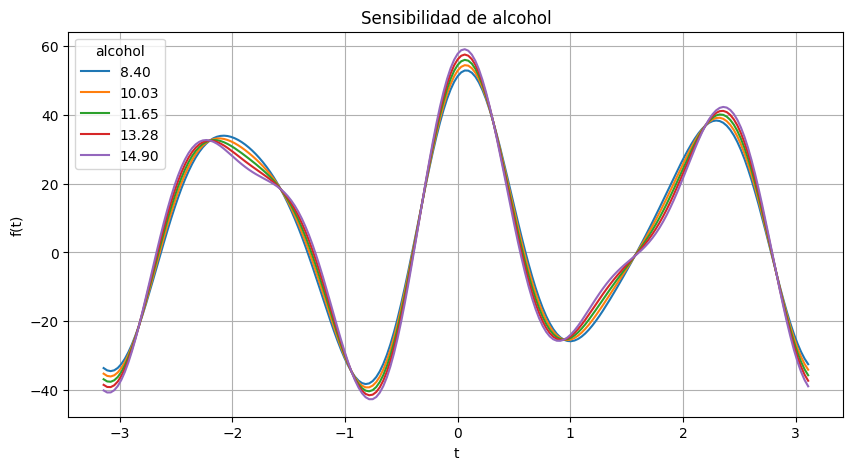

In [41]:
attribute = "alcohol"

sample = X.iloc[0].copy()

values = np.linspace(
    X[attribute].min(),
    X[attribute].max(),
    5
)

plt.figure(figsize=(10, 5))

for v in values:

    modified = sample.copy()
    modified[attribute] = v

    curve, t = encode(
        pd.DataFrame([modified]),
        normalize="none",
        return_t=True
    )

    plt.plot(
        t,
        curve[0],
        label=f"{v:.2f}"
    )

plt.title(f"Sensibilidad de {attribute}")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend(title=attribute)
plt.grid()
plt.show()

In [ ]:
results = []

for v in values:

    modified = sample.copy()
    modified[attribute] = v

    curve = encode(
        pd.DataFrame([modified]),
        normalize="none"
    )[0]

    h0, _ = persistence_diagram(curve)

    stats = persistence_statistics(h0)

    stats["alcohol"] = v

    results.append(stats)

pd.DataFrame(results)

,num_pairs,total_persistence,max_life,entropy,value
0,0,0.0,0.0,0.0,8.400
1,0,0.0,0.0,0.0,10.025
2,0,0.0,0.0,0.0,11.650
3,0,0.0,0.0,0.0,13.275
4,0,0.0,0.0,0.0,14.900
